## LSTM + GRU Stock Predictor

In [3]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn


In [4]:
tickers = ["AAPL", "MSFT", "GOOG"]

def load_multiple_stocks(tickers, periods="2y"):
    dfs = []
    for ticker in tickers:
        df = yf.download(ticker, period=periods)
        df = df[['Close']]
        df.columns = [ticker]
        dfs.append(df)

    combined = pd.concat(dfs, axis=1)
    combined.dropna(inplace=True)
    return combined

df = load_multiple_stocks(tickers)
df.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,AAPL,MSFT,GOOG
Date,,,
2024-03-21,169.824432,422.879333,147.528793
2024-03-22,170.726242,422.258850,150.534134
2024-03-25,169.309143,416.467773,149.919144
2024-03-26,168.179443,415.276062,150.464676
2024-03-27,171.746948,415.059326,150.702744


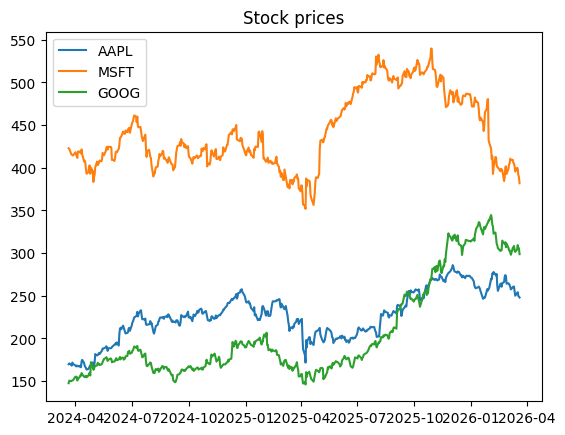

In [5]:
plt.Figure(figsize=(12,6))
for col in df.columns:
    plt.plot(df[col], label=col)

plt.title("Stock prices")
plt.legend()
plt.show()

In [6]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df.values)

In [7]:
def create_seq(data, seq_len=60):
    X, y = [], []

    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

SEQ_LEN=60
X, y = create_seq(scaled_data, SEQ_LEN)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (441, 60, 3)
y shape: (441, 3)


In [8]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [9]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [10]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=50, num_layers=2):
        super().__init__()

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, input_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

In [11]:
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size=50, num_layers=2):
        super().__init__()
        
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, input_size)
        
    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

In [12]:
input_size = X.shape[2]

hidden_sizes = [32, 50]
num_layers_list = [1, 2]
learning_rates = [0.001, 0.0005]

best_loss = float('inf')
best_config = None

for hidden_size in hidden_sizes:
    for num_layers in num_layers_list:
        for lr in learning_rates:
            
            model = LSTMModel(input_size, hidden_size, num_layers)
            optimizer = torch.optim.Adam(model.parameters(), lr=lr)
            criterion = nn.MSELoss()
            
            for epoch in range(3):
                outputs = model(X_train)
                loss = criterion(outputs, y_train)
                
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            
            print(f"HS:{hidden_size}, NL:{num_layers}, LR:{lr}, Loss:{loss.item():.5f}")
            
            if loss.item() < best_loss:
                best_loss = loss.item()
                best_config = (hidden_size, num_layers, lr)

print("Best config:", best_config)

HS:32, NL:1, LR:0.001, Loss:0.22928
HS:32, NL:1, LR:0.0005, Loss:0.27776
HS:32, NL:2, LR:0.001, Loss:0.25326
HS:32, NL:2, LR:0.0005, Loss:0.17911
HS:50, NL:1, LR:0.001, Loss:0.11360
HS:50, NL:1, LR:0.0005, Loss:0.32185
HS:50, NL:2, LR:0.001, Loss:0.15134
HS:50, NL:2, LR:0.0005, Loss:0.20093
Best config: (50, 1, 0.001)


In [16]:
hidden_size, num_layers, lr = best_config

lstm_model = LSTMModel(input_size, hidden_size, num_layers)
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=lr)
criterion = nn.MSELoss()

EPOCHS = 10000

for epoch in range(EPOCHS):
    outputs = lstm_model(X_train)
    loss = criterion(outputs, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    print(f"LSTM Epoch {epoch+1}, Loss: {loss.item():.6f}")

LSTM Epoch 1, Loss: 0.192653
LSTM Epoch 2, Loss: 0.183076
LSTM Epoch 3, Loss: 0.173887
LSTM Epoch 4, Loss: 0.165024
LSTM Epoch 5, Loss: 0.156439
LSTM Epoch 6, Loss: 0.148097
LSTM Epoch 7, Loss: 0.139966
LSTM Epoch 8, Loss: 0.132016
LSTM Epoch 9, Loss: 0.124216
LSTM Epoch 10, Loss: 0.116531
LSTM Epoch 11, Loss: 0.108929
LSTM Epoch 12, Loss: 0.101379
LSTM Epoch 13, Loss: 0.093856
LSTM Epoch 14, Loss: 0.086340
LSTM Epoch 15, Loss: 0.078825
LSTM Epoch 16, Loss: 0.071319
LSTM Epoch 17, Loss: 0.063850
LSTM Epoch 18, Loss: 0.056474
LSTM Epoch 19, Loss: 0.049289
LSTM Epoch 20, Loss: 0.042452
LSTM Epoch 21, Loss: 0.036208
LSTM Epoch 22, Loss: 0.030924
LSTM Epoch 23, Loss: 0.027130
LSTM Epoch 24, Loss: 0.025511
LSTM Epoch 25, Loss: 0.026635
LSTM Epoch 26, Loss: 0.029965
LSTM Epoch 27, Loss: 0.033105
LSTM Epoch 28, Loss: 0.033987
LSTM Epoch 29, Loss: 0.032580
LSTM Epoch 30, Loss: 0.029978
LSTM Epoch 31, Loss: 0.027278
LSTM Epoch 32, Loss: 0.025134
LSTM Epoch 33, Loss: 0.023757
LSTM Epoch 34, Loss

In [17]:
gru_model = GRUModel(input_size)

optimizer = torch.optim.Adam(gru_model.parameters(), lr=0.001)
criterion = nn.MSELoss()

for epoch in range(100):
    outputs = gru_model(X_train)
    loss = criterion(outputs, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    print(f"GRU Epoch {epoch+1}, Loss: {loss.item():.6f}")

GRU Epoch 1, Loss: 0.242895
GRU Epoch 2, Loss: 0.213022
GRU Epoch 3, Loss: 0.185187
GRU Epoch 4, Loss: 0.159212
GRU Epoch 5, Loss: 0.135013
GRU Epoch 6, Loss: 0.112602
GRU Epoch 7, Loss: 0.092088
GRU Epoch 8, Loss: 0.073676
GRU Epoch 9, Loss: 0.057677
GRU Epoch 10, Loss: 0.044504
GRU Epoch 11, Loss: 0.034635
GRU Epoch 12, Loss: 0.028528
GRU Epoch 13, Loss: 0.026410
GRU Epoch 14, Loss: 0.027908
GRU Epoch 15, Loss: 0.031707
GRU Epoch 16, Loss: 0.035792
GRU Epoch 17, Loss: 0.038413
GRU Epoch 18, Loss: 0.038852
GRU Epoch 19, Loss: 0.037370
GRU Epoch 20, Loss: 0.034722
GRU Epoch 21, Loss: 0.031700
GRU Epoch 22, Loss: 0.028890
GRU Epoch 23, Loss: 0.026614
GRU Epoch 24, Loss: 0.024973
GRU Epoch 25, Loss: 0.023928
GRU Epoch 26, Loss: 0.023359
GRU Epoch 27, Loss: 0.023126
GRU Epoch 28, Loss: 0.023092
GRU Epoch 29, Loss: 0.023142
GRU Epoch 30, Loss: 0.023194
GRU Epoch 31, Loss: 0.023189
GRU Epoch 32, Loss: 0.023092
GRU Epoch 33, Loss: 0.022887
GRU Epoch 34, Loss: 0.022572
GRU Epoch 35, Loss: 0.0

In [18]:
lstm_model.eval()
gru_model.eval()

with torch.no_grad():
    lstm_preds = lstm_model(X_test).numpy()
    gru_preds = gru_model(X_test).numpy()

In [19]:
lstm_preds = scaler.inverse_transform(lstm_preds)
gru_preds = scaler.inverse_transform(gru_preds)
actual = scaler.inverse_transform(y_test.numpy())

In [20]:
def predict_future(model, last_sequence, steps=7):
    model.eval()
    seq = last_sequence.clone()
    preds = []
    
    for _ in range(steps):
        with torch.no_grad():
            pred = model(seq.unsqueeze(0))
        
        preds.append(pred.numpy()[0])
        
        seq = torch.cat((seq[1:], pred), dim=0)
    
    return np.array(preds)

last_seq = X_test[-1]

future_preds = predict_future(lstm_model, last_seq, 7)
future_preds = scaler.inverse_transform(future_preds)

print("Next 7 days prediction:\n", future_preds)

Next 7 days prediction:
 [[261.82455 406.98334 221.45938]
 [263.62186 404.13672 215.44044]
 [261.71704 406.70697 215.4386 ]
 [258.08368 409.15268 216.20288]
 [254.53827 410.6514  216.566  ]
 [251.7393  412.57764 217.31267]
 [250.04512 417.14978 219.6463 ]]
